Per prima cosa carico il dataset e utlizzo alcuni metodi per capirne la struttura

In [136]:
import pandas as pd

#carico il dataset
df = pd.read_csv('/content/heart.csv')

#mostro dei dati per capirne la struttura

display(df.head())
df.info()
df.describe()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       917 non-null    float64
 4   Cholesterol     746 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 86.2+ KB


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,917.000000,746.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.540894,244.635389,0.233115,136.809368,0.887364,0.553377
std,9.432617,17.999749,59.153524,0.423046,25.460334,1.066570,0.497414
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,207.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,237.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,275.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [137]:
#controllo i valori nulli che sono presenti
display(df.isnull().sum())

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,1
Cholesterol,172
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


Per risolvere il problema dei valori null all'interno del nostro dataset, faremo un imputazione dei dati con le metriche più opportune

In [138]:
#per restingBP in quanto un solo valore mancante la mediana andrà più che bene
median_restingbp = df['RestingBP'].median()
df['RestingBP'].fillna(median_restingbp, inplace=True)
print(f"Valore mancante di RestingBP imputato con la mediana: {median_restingbp}")

#Verifico che ora restingBP abbia tutti i valori
display(df[['RestingBP', 'Cholesterol']].isnull().sum())

Valore mancante di RestingBP imputato con la mediana: 130.0


/tmp/ipykernel_4224/848918133.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['RestingBP'].fillna(median_restingbp, inplace=True)


,0
RestingBP,0
Cholesterol,172


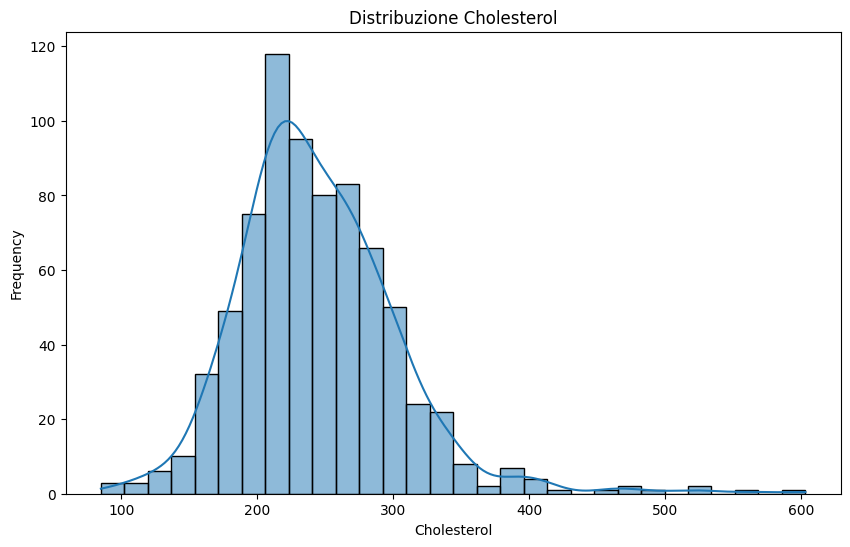

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

#Visualizzo la distribuzione di cholesterol per capire quale strategia di imputazione è la migliore
#per questo caso, anche perche cholesterol ha parecchi null
plt.figure(figsize=(10, 6))
sns.histplot(df['Cholesterol'].dropna(), kde=True, bins=30)
plt.title('Distribuzione Cholesterol')
plt.xlabel('Cholesterol')
plt.ylabel('Frequency')
plt.show()

Dal grafico capisco che cholesterol ha molti outlier e che quindi utilizzare la mediana come imputazione dei dati è probabilmente la scelta migliore

In [140]:
# imputazione dei valori mancanti nel cholesterol con la mediana
median_cholesterol = df['Cholesterol'].median()
df['Cholesterol'].fillna(median_cholesterol, inplace=True)
print(f"Valori mancanti di cholesterol imputati con: {median_cholesterol}")

#verifico che non ci siano più valori mancanti
display(df[['RestingBP', 'Cholesterol']].isnull().sum())

Valori mancanti di cholesterol imputati con: 237.0


/tmp/ipykernel_4224/1401113943.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Cholesterol'].fillna(median_cholesterol, inplace=True)


,0
RestingBP,0
Cholesterol,0


Dopo che ho sistemato i valori null, procedo con analizzare le colonne categoriche per capire se nominali, ordinali e come convertirle

In [141]:
print("\nValori unici e numero delle colonne categoriche")
for column in df.select_dtypes(include='object').columns:
    print(f"\nColumn: {column}")
    print(df[column].value_counts())
    print("----------------------")


Valori unici e numero delle colonne categoriche

Column: Sex
Sex
M    725
F    193
Name: count, dtype: int64
----------------------

Column: ChestPainType
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
----------------------

Column: RestingECG
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
----------------------

Column: ExerciseAngina
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
----------------------

Column: ST_Slope
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64
----------------------


Tutte le variabili categoriche presenti non sono riconducibili a categoriche ordinali, dunque utilizzerò per tutte come metodo di encoding il one hot encoding

In [142]:
# identifico e faccio una lista delle colonne categoriche
categorical_cols = df.select_dtypes(include='object').columns

print(f"colonne categoriche da fare encoding: {list(categorical_cols)}")

#Faccio lo One hot-encoding, creando un dataframe post-encoding per cautela
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

#visualizzo il nuovo dataframe
display(df_encoded.head())

print(df_encoded.shape)

df_encoded.info()

colonne categoriche da fare encoding: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


(918, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    float64
 2   Cholesterol        918 non-null    float64
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   Oldpeak            918 non-null    float64
 6   HeartDisease       918 non-null    int64  
 7   Sex_M              918 non-null    bool   
 8   ChestPainType_ATA  918 non-null    bool   
 9   ChestPainType_NAP  918 non-null    bool   
 10  ChestPainType_TA   918 non-null    bool   
 11  RestingECG_Normal  918 non-null    bool   
 12  RestingECG_ST      918 non-null    bool   
 13  ExerciseAngina_Y   918 non-null    bool   
 14  ST_Slope_Flat      918 non-null    bool   
 15  ST_Slope_Up        918 non-null    bool   
dtypes: bool(9), floa

Ora che abbiamo preparato i dati, possiamo scegliere un modello di classificazione. Un buon punto di partenza per un problema di classificazione binaria(heart_disease 0, 1) è la Regressione Logistica

In [143]:
from sklearn.model_selection import train_test_split

# Separo le feature (X) dalla variabile target (y)
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Divido il dataset in training set e test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape del set di addestramento (X_train): {X_train.shape}")
print(f"Shape del set di test (X_test): {X_test.shape}")
print(f"Shape del target di addestramento (y_train): {y_train.shape}")
print(f"Shape del target di test (y_test): {y_test.shape}")

Shape del set di addestramento (X_train): (734, 15)
Shape del set di test (X_test): (184, 15)
Shape del target di addestramento (y_train): (734,)
Shape del target di test (y_test): (184,)


Procediamo con la scalatura delle feature numeriche utilizzando `StandardScaler`.Escludendo le colonne binarie

In [144]:
from sklearn.preprocessing import StandardScaler

# Inizializzo lo StandardScaler
scaler = StandardScaler()

# Identifico le colonne numeriche da scalare. Escludo le colonne booleane e 'FastingBS' che è binaria.
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.drop('FastingBS')

# Applico lo scaler solo alle colonne numeriche del training set e del test set
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Dati di addestramento dopo la scalatura (prime 5 righe):")
display(X_train_scaled.head())

print("Dati di test dopo la scalatura (prime 5 righe):")
display(X_test_scaled.head())

Dati di addestramento dopo la scalatura (prime 5 righe):


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
485,0.970012,0.339016,-0.514028,1,-0.324520,0.317046,True,True,False,False,False,True,True,True,False
486,0.122028,-1.266031,-0.569339,1,1.689837,-0.440356,True,True,False,False,False,True,False,False,True
117,0.546020,-0.159102,1.716858,1,-0.247045,0.601071,False,False,False,False,False,True,True,True,False
361,-0.725956,1.501291,-0.145286,0,-0.479470,-0.819056,True,False,False,False,True,False,True,True,False
296,-0.407962,0.671094,-0.145286,1,0.101594,-0.156330,True,False,False,False,True,False,True,True,False


Dati di test dopo la scalatura (prime 5 righe):


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
356,-0.831954,-0.989299,-0.145286,0,-0.905584,0.601071,True,False,False,False,True,False,True,True,False
763,0.440022,-0.048409,-0.384968,0,1.418673,2.210549,True,False,True,False,False,False,False,False,True
817,0.652018,-0.435834,0.241892,0,0.179069,1.831848,True,False,False,False,False,False,True,True,False
735,-0.513960,-0.712567,-1.048703,0,0.101594,1.074447,True,False,True,False,True,False,False,True,False
892,-1.573940,0.283669,-0.458716,0,0.605183,-0.819056,False,False,True,False,True,False,False,True,False


Ora che i dati sono stati scalati, useremo `X_train_scaled` e `X_test_scaled` per addestrare e valutare il modello di Regressione Logistica. Modifico la cella precedente per riflettere questo cambiamento.

In [145]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Inizializzo il modello di Regressione Logistica
model = LogisticRegression(random_state=67, solver='liblinear', max_iter=1000)

# Addestro il modello sul training data (ora usando i dati scalati)
model.fit(X_train_scaled, y_train)

# Faccio le predizioni sul test data (ora usando i dati scalati)
y_pred = model.predict(X_test_scaled)

# Valuto le prestazioni del modello
print("Accuracy del modello:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy del modello: 0.8913043478260869

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184


Confusion Matrix:
 [[71 11]
 [ 9 93]]


Il modello sembra abbastanza buono, con un alta accuratezza, specialmente per quanto riguarda il recall(quindi evitando falsi negativi) che in un contesto medico potrebbe essere ideale

Ora cerchiamo di implementare un modello di rete neurale e confrontarlo con questo più semplice di regressione logica

In [146]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Converti i dati scalati in tensori PyTorch
# Converte le colonne booleane in float prima di passare a torch.tensor
X_train_tensor = torch.tensor(X_train_scaled.astype(float).values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1) # Aggiungi una dimensione per la loss
X_test_tensor = torch.tensor(X_test_scaled.astype(float).values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Definisco il modello di rete neurale in PyTorch con un solo layer nascosto e Dropout
class DiseaseNN(nn.Module):
    def __init__(self, input_size):
        super(DiseaseNN, self).__init__()
        self.layer_1 = nn.Linear(input_size, 16) # Un solo layer nascosto con 16 neuroni
        self.relu_1 = nn.ReLU()
        self.dropout_1 = nn.Dropout(0.3) # Un solo layer di dropout
        self.output_layer = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.relu_1(x)
        x = self.dropout_1(x) # Applico dropout
        x = self.output_layer(x)
        x = self.sigmoid(x)
        return x

# Inizializza il modello
input_size = X_train_scaled.shape[1]
model_nn_pytorch = DiseaseNN(input_size)

# Definisco la funzione di perdita che si utilizza
#per i problemi di classificazione è la BCEloss e l'ottimizzatore Adam:
criterion = nn.BCELoss()
optimizer = optim.Adam(model_nn_pytorch.parameters(), lr=0.001)

# Addestra il modello
epochs = 250
for epoch in range(epochs):
    # Forward pass
    outputs = model_nn_pytorch(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

print("Addestramento completato.")

# Faccio le predizioni sul test data
model_nn_pytorch.eval() # Imposta il modello in modalità valutazione
with torch.no_grad(): # Disabilita il calcolo del gradiente
    y_pred_proba_nn = model_nn_pytorch(X_test_tensor)
    y_pred_nn = (y_pred_proba_nn > 0.5).int().numpy() # Converti in numpy e poi in int per sklearn

# Valuto le prestazioni del modello di rete neurale
print("Accuracy del modello di Rete Neurale (PyTorch):", accuracy_score(y_test, y_pred_nn))
print("\nClassification Report della Rete Neurale (PyTorch):\n", classification_report(y_test, y_pred_nn))
print("\nConfusion Matrix della Rete Neurale (PyTorch):\n", confusion_matrix(y_test, y_pred_nn))

Epoch [1/250], Loss: 0.7296
Epoch [2/250], Loss: 0.7260
Epoch [3/250], Loss: 0.7297
Epoch [4/250], Loss: 0.7229
Epoch [5/250], Loss: 0.7207
Epoch [6/250], Loss: 0.7225
Epoch [7/250], Loss: 0.7166
Epoch [8/250], Loss: 0.7156
Epoch [9/250], Loss: 0.7138
Epoch [10/250], Loss: 0.7078
Epoch [11/250], Loss: 0.7073
Epoch [12/250], Loss: 0.7044
Epoch [13/250], Loss: 0.6984
Epoch [14/250], Loss: 0.7020
Epoch [15/250], Loss: 0.7007
Epoch [16/250], Loss: 0.6962
Epoch [17/250], Loss: 0.6963
Epoch [18/250], Loss: 0.6933
Epoch [19/250], Loss: 0.6916
Epoch [20/250], Loss: 0.6923
Epoch [21/250], Loss: 0.6862
Epoch [22/250], Loss: 0.6857
Epoch [23/250], Loss: 0.6828
Epoch [24/250], Loss: 0.6807
Epoch [25/250], Loss: 0.6798
Epoch [26/250], Loss: 0.6828
Epoch [27/250], Loss: 0.6784
Epoch [28/250], Loss: 0.6788
Epoch [29/250], Loss: 0.6751
Epoch [30/250], Loss: 0.6718
Epoch [31/250], Loss: 0.6706
Epoch [32/250], Loss: 0.6695
Epoch [33/250], Loss: 0.6675
Epoch [34/250], Loss: 0.6658
Epoch [35/250], Loss: 0

Il nostro modello neurale non si presta così bene per questo tipo di dataset, forse perche troppo piccolo, anche priovando a modificare layer e funzioni di attivazioni l'accuracy rimane in questo range, dimostrando una perdita rispetto il nostro modello di regressione logica più semplice

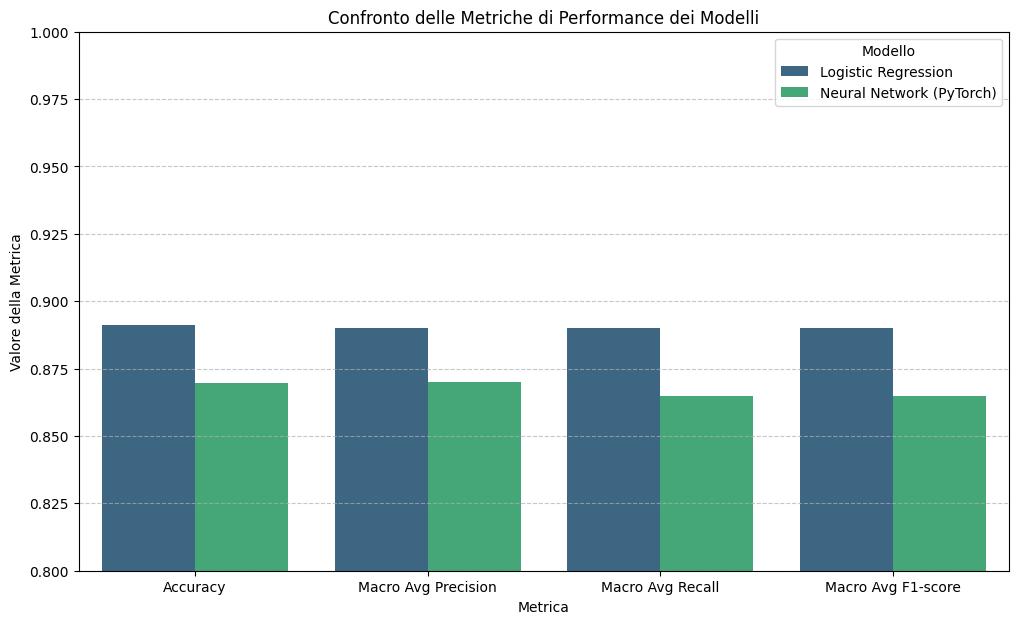

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Dati delle metriche dai modelli precedenti
metrics_data = {
    'Model': ['Logistic Regression', 'Logistic Regression', 'Logistic Regression', 'Logistic Regression', 'Neural Network (PyTorch)', 'Neural Network (PyTorch)', 'Neural Network (PyTorch)', 'Neural Network (PyTorch)'],
    'Metric': ['Accuracy', 'Macro Avg Precision', 'Macro Avg Recall', 'Macro Avg F1-score', 'Accuracy', 'Macro Avg Precision', 'Macro Avg Recall', 'Macro Avg F1-score'],
    'Value': [
        0.8913, # Logistic Regression Accuracy
        0.89,   # Logistic Regression Macro Avg Precision
        0.89,   # Logistic Regression Macro Avg Recall
        0.89,   # Logistic Regression Macro Avg F1-score
        0.8696, # Neural Network Accuracy
        (0.86 + 0.88) / 2, # Neural Network Macro Avg Precision
        (0.84 + 0.89) / 2, # Neural Network Macro Avg Recall
        (0.85 + 0.88) / 2  # Neural Network Macro Avg F1-score
    ]
}

df_metrics = pd.DataFrame(metrics_data)

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Value', hue='Model', data=df_metrics, palette='viridis')
plt.title('Confronto delle Metriche di Performance dei Modelli')
plt.ylabel('Valore della Metrica')
plt.xlabel('Metrica')
plt.ylim(0.8, 1.0) # Imposta un limite inferiore per evidenziare le differenze
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Modello')
plt.show()

### Analisi Critica dei Risultati

Analizziamo i risultati ottenuti dai due modelli, la Regressione Logistica e la Rete Neurale, sulla base delle metriche calcolate dopo il primo split train-test

#### 1. Risultati Numerici Dettagliati:

**Regressione Logistica:**
*   **Accuracy:** 0.8913
*   **Macro Avg Precision:** 0.89
*   **Macro Avg Recall:** 0.89
*   **Macro Avg F1-score:** 0.89

**Rete Neurale:**
*   **Accuracy:** 0.8696
*   **Macro Avg Precision:** 0.87
*   **Macro Avg Recall:** 0.865
*   **Macro Avg F1-score:** 0.865

#### 2. Interpretazione e Confronto Critico:

Dai numeri, è evidente che in questa specifica casistica, la **Regressione Logistica ha superato la Rete Neurale** su tutte le metriche chiave (Accuracy, Precision, Recall, F1-score). Sebbene la differenza non sia enorme (circa il 2-3%), in un contesto medico, anche piccole variazioni possono essere significative.

**Perché la Regressione Logistica ha performato meglio in questo caso?**

*   **Dimensione del Dataset:** Il nostro dataset è relativamente piccolo (918 osservazioni). Le Reti Neurali tendono a brillare con volumi di dati molto più ampi, dove possono imparare pattern complessi e gerarchici. Su dataset ridotti, sono più inclini all'overfitting (imparare il rumore nei dati di addestramento e non generalizzare bene) o semplicemente non riescono a sfruttare la loro potenza intrinseca.

*   **Complessità delle Relazioni:** Sembra che le relazioni tra le feature e la variabile target `HeartDisease` non siano eccessivamente complesse o non lineari al punto da richiedere la sofisticazione di una rete neurale. Un modello lineare come la Regressione Logistica è stato sufficiente a catturare i pattern più rilevanti.



*   **Overfitting della Rete Neurale:** Nonostante i tentativi di ottimizzazione (aggiunta di Dropout, tuning di learning rate ed epoche), la Rete Neurale ha mostrato difficoltà a superare la Regressione Logistica. Questo suggerisce che, per questo specifico problema e dataset, la rete neurale potrebbe essere stata eccessivamente complessa, portando a un leggero overfitting o semplicemente a una difficoltà nell'apprendimento di pattern generalizzabili, a causa della limitata quantità di dati e della potenziale linearità sottostante delle relazioni.

*   **Robustezza e Stabilità:** Il fatto che la Regressione Logistica abbia ottenuto risultati simili o migliori con un modello più semplice indica una maggiore robustezza per questo tipo di dati. Le reti neurali, soprattutto su dataset piccoli, possono essere più sensibili alla fase di inizializzazione dei pesi e alla scelta degli iperparametri.

#### 3. Vantaggi e Limiti Specifici per Questa Casistica:

**Regressione Logistica:**
*   **Vantaggi:** Alte prestazioni con un modello semplice, alta interpretabilità, efficienza computazionale, minore rischio di overfitting su dataset piccoli.
*   **Limiti:** Potrebbe non catturare relazioni estremamente complesse se presenti (ma in questo caso non sembra essere un fattore limitante significativo).

**Rete Neurale:**
*   **Vantaggi:** Potenzialmente in grado di apprendere relazioni non lineari e complesse (non pienamente sfruttato qui), flessibilità architetturale.
*   **Limiti:** Prestazioni inferiori al modello più semplice, maggiore complessità computazionale, minor interpretabilità, rischio di overfitting su dataset piccoli, richiede più tuning di iperparametri.

#### Conclusione Preliminare:

Per questo problema specifico di previsione delle malattie cardiache con il dataset a disposizione, la **Regressione Logistica** si è dimostrata il modello più efficace ed efficiente. Nonostante l'attrattiva delle reti neurali per la loro capacità di gestire complessità, in scenari con dataset di dimensioni modeste e relazioni non eccessivamente non lineari, i modelli più semplici e interpretabili spesso rappresentano la scelta migliore.